

---

# 🧯 **Regularization in Deep Learning**

> 🎯 Regularization = **Controlling model complexity** to prevent **overfitting** and improve **generalization** on unseen data.

---

## ❓ Why Do We Need Regularization?

In deep learning, we train models with **millions of parameters**, which can:
- Memorize the training data (😱 overfitting)
- Perform poorly on test/real-world data

👉 **Regularization techniques** add constraints or penalties to **reduce overfitting** and make the model more **robust**.

---

## 🚨 Signs of Overfitting:
| Metric             | Observation                  |
|--------------------|------------------------------|
| Training Loss      | Decreasing 🟢                |
| Validation Loss    | Decreasing then increasing 🔴 |
| Accuracy (Train)   | High 🔼                      |
| Accuracy (Test)    | Low 🔽                       |

✅ Regularization fixes this!

---

## 🔑 **Types of Regularization in Deep Learning**

---

### 🔹 **1. L1 and L2 Regularization (Weight Penalty)**

Adds a **penalty term** to the loss function to discourage large weights.

### 🧮 Modified Loss Function:
$
\text{Loss} = \mathcal{L}(\hat{y}, y) + \lambda R(w)
$
Where:
- $ \mathcal{L} $ = original loss (e.g. MSE, cross-entropy)
- $ R(w) $ = regularization term
- $ \lambda $ = regularization strength (hyperparameter)

#### 🔸 L1 Regularization (Lasso):
$
R(w) = \sum |w_i|
$
- Encourages **sparsity** (many weights become zero)
- Good for **feature selection**

#### 🔸 L2 Regularization (Ridge):
$
R(w) = \sum w_i^2
$
- Encourages **smaller weights**
- Helps with **smooth generalization**

**✅ Most common: L2 (a.k.a. weight decay)**

---

### 🔹 **2. Dropout (Random Deactivation)**

Randomly **drops neurons** during training to prevent co-adaptation.

```python
from tensorflow.keras.layers import Dropout
Dropout(0.5)  # Drop 50% of neurons randomly during training
```

✅ Prevents **over-reliance** on specific neurons  
✅ Makes model act like an **ensemble**

---

### 🔹 **3. Early Stopping**

Stops training **when validation loss stops improving** to avoid overfitting.

```python
from keras.callbacks import EarlyStopping
EarlyStopping(monitor='val_loss', patience=5)
```

✅ Saves training time  
✅ Keeps model at the **best generalization point**

---

### 🔹 **4. Data Augmentation**

Applies random **transformations** to training data (images, text, etc.) to simulate more examples.

```python
from keras.preprocessing.image import ImageDataGenerator
ImageDataGenerator(rotation_range=20, zoom_range=0.1, ...)
```

✅ Expands training set  
✅ Helps model generalize better  
✅ Especially useful in **CV and NLP**

---

### 🔹 **5. Batch Normalization**

Normalizes intermediate layer outputs to stabilize and speed up training.

✅ Acts as **implicit regularizer**  
✅ Reduces internal covariate shift  
✅ Can reduce need for dropout

---

### 🔹 **6. Label Smoothing**

Softens the hard labels in classification problems:
$
y_{\text{smooth}} = y \cdot (1 - \epsilon) + \frac{\epsilon}{K}
$

✅ Prevents the model from becoming **overconfident**  
✅ Improves generalization in classification tasks

---

## 🧪 Example: L2 Regularization in Keras

```python
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dense

Dense(64, activation='relu', kernel_regularizer=l2(0.01))
```

---

## ⚙️ Comparing Regularization Techniques

| Technique         | Helps With       | When to Use                       |
|------------------|------------------|----------------------------------|
| **L1/L2**         | Large weights    | General-purpose regularization   |
| **Dropout**       | Co-adaptation    | Deep MLPs, CNNs                  |
| **Early Stopping**| Overfitting      | Any training with validation set |
| **Data Aug.**     | Data scarcity    | Computer Vision, NLP             |
| **BatchNorm**     | Gradient stability | All types of deep nets           |
| **Label Smoothing**| Overconfidence | Classification with soft targets |

---

## 📚 Summary

| ✅ Regularization Type | 🔧 Purpose |
|------------------------|------------|
| **L1 / L2**             | Penalize large weights |
| **Dropout**             | Prevent over-reliance on neurons |
| **Early Stopping**      | Stop before overfitting |
| **Data Augmentation**   | Improve generalization with limited data |
| **Batch Normalization** | Stabilize learning and improve performance |
| **Label Smoothing**     | Reduce overconfidence in classification |

---

## 💡 TL;DR

> **"Regularization is your model’s defense system against overfitting. Use it wisely."** 🛡️

---

## **Let's Practice**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2)

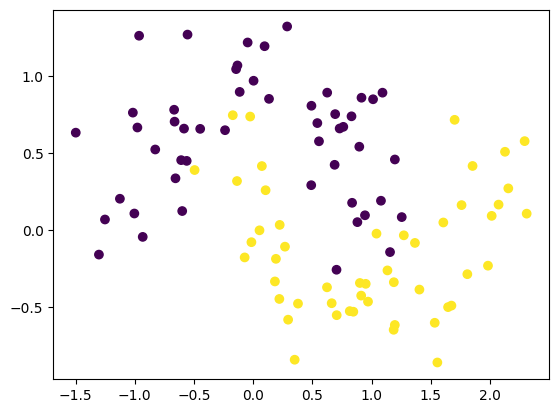

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [4]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


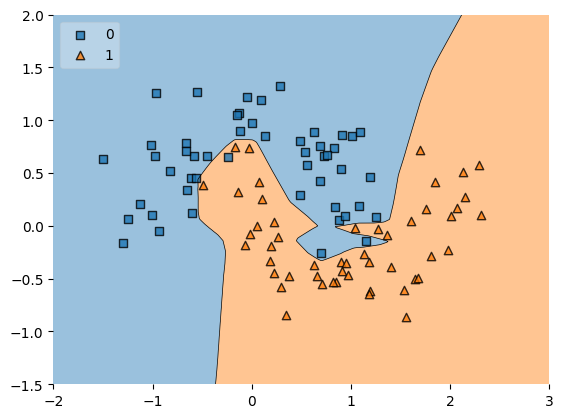

In [6]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

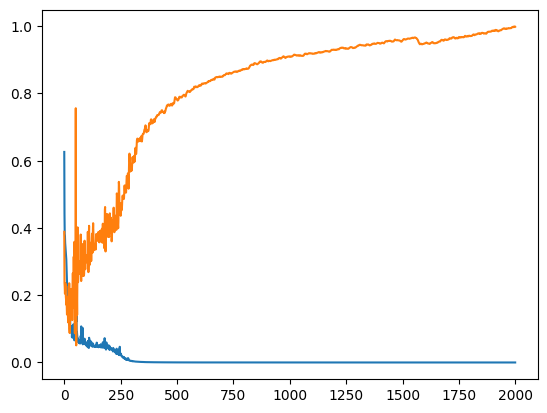

In [7]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.show()

In [8]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


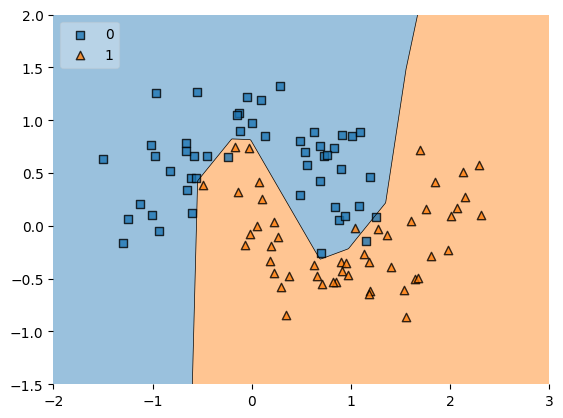

In [10]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

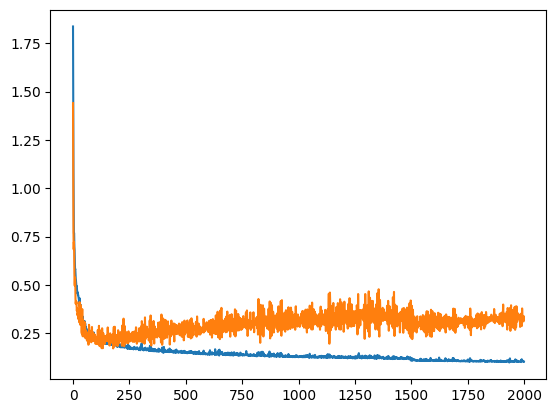

In [11]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.show()

In [12]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

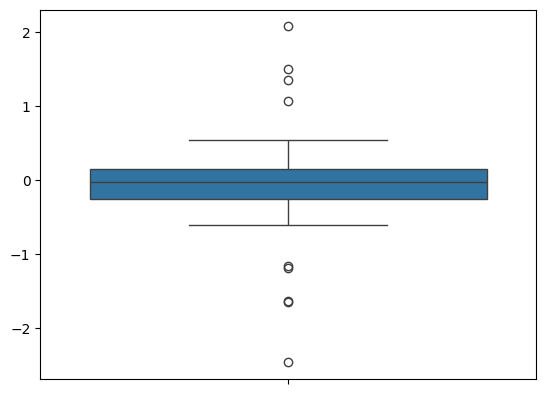

In [13]:
sns.boxplot(model1_weight_layer1)
plt.show()

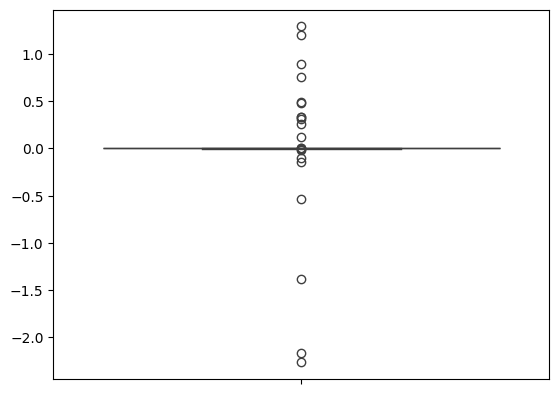

In [14]:
sns.boxplot(model2_weight_layer1)
plt.show()

In [15]:
model1_weight_layer1.min()

np.float32(-2.457993)

In [16]:
model2_weight_layer1.min()

np.float32(-2.2645438)

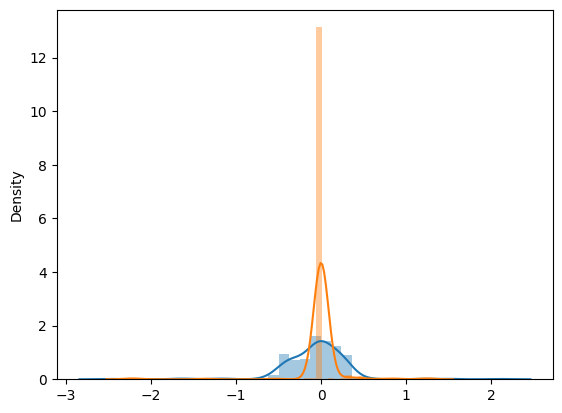

In [17]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)
plt.show()

In [18]:
model1.get_weights()[0].reshape(256)

array([-9.29038674e-02,  2.94426143e-01,  8.93358365e-02, -4.12478775e-01,
       -5.14828563e-02, -5.00555895e-03, -3.75773281e-01,  2.41002485e-01,
        2.68684298e-01, -1.60760492e-01,  2.06217989e-01, -3.62162769e-01,
       -4.64444250e-01,  2.35024616e-01, -4.45899218e-01, -3.32239687e-01,
        3.16266477e-01, -1.46600038e-01, -3.77080560e-01, -4.45282876e-01,
        6.40863478e-02, -4.24927711e-01,  3.18936020e-01, -7.45432079e-02,
       -2.13336259e-01,  2.28445128e-01, -2.74213739e-02,  1.96379945e-01,
        9.88804642e-03,  1.51812822e-01, -5.42057566e-02, -6.25396296e-02,
       -3.78266245e-01, -2.32375041e-01, -4.02429491e-01,  2.66851008e-01,
       -2.81265885e-01, -4.46773618e-01, -8.00680295e-02, -1.40689462e-01,
       -4.51519936e-01,  3.08231622e-01,  4.52008657e-02,  2.97351480e-01,
       -3.54833812e-01, -1.01131564e-02, -3.55994880e-01, -4.77000564e-01,
        2.34114025e-02, -2.10804585e-02,  2.60226488e-01,  2.68799424e-01,
        1.79902643e-01,  

---